In [1]:
import numpy as np
from qiskit_aer import AerSimulator

backend = AerSimulator()

print(backend.name)

aer_simulator


SparsePauliOp(['IIIIIIII'],
              coeffs=[0.+0.j])
SparsePauliOp(['IIIIIIIZ'],
              coeffs=[-0.5+0.j])
>>> Observable: ['IIIIIIZZ', 'IIIIIZZI', 'IIIIZZII', 'IIIZZIII', 'IIZZIIII', 'IZZIIIII',
 'ZZIIIIII']
>>> Parameters: ParameterView([ParameterVectorElement(β[0]), ParameterVectorElement(β[1]), ParameterVectorElement(γ[0]), ParameterVectorElement(γ[1])])


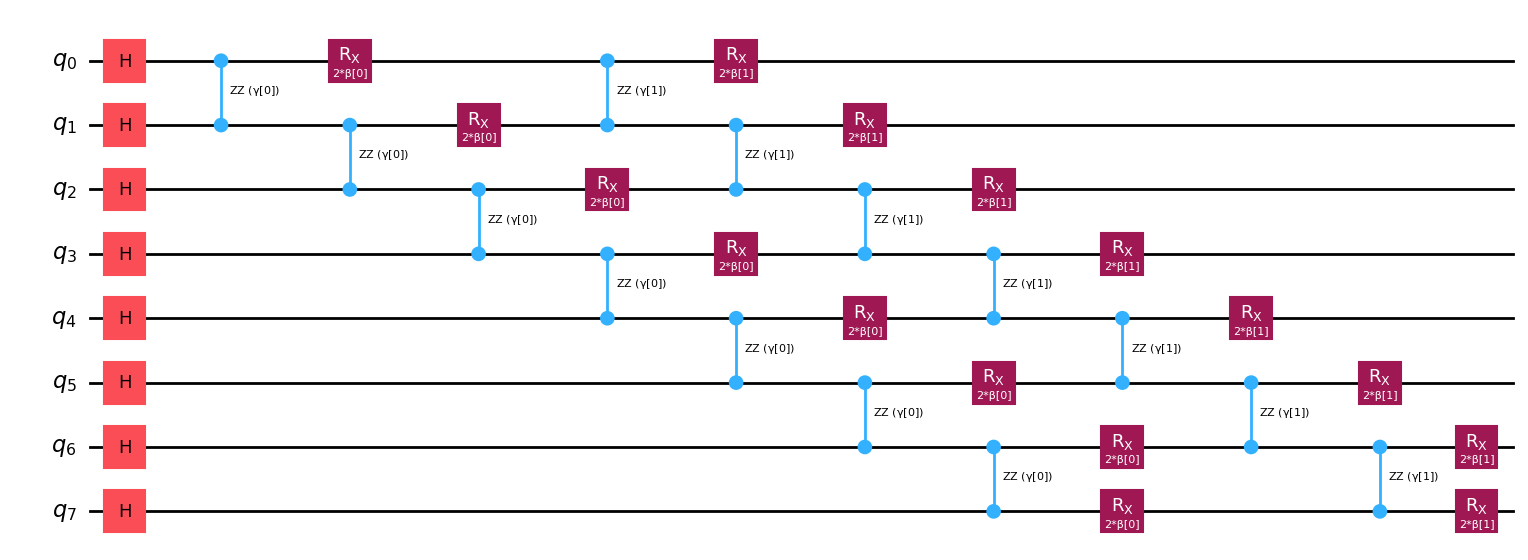

In [2]:
from qiskit.primitives.containers.observables_array import ObservablesArray
from qiskit.circuit.library import qaoa_ansatz, PauliEvolutionGate
from qiskit.circuit import Parameter
from qiskit.quantum_info import SparsePauliOp
from itertools import product
num_qubits = 8
entanglement = [tuple(edge) for edge in zip(range(num_qubits-1), range(1,num_qubits))]
observable = SparsePauliOp.from_sparse_list(
    [("ZZ", [i, j], 0.5) for i, j in entanglement]#+[("ZZ", [2,4], 0.5)]
    ,
    num_qubits=num_qubits,
)

circuit = qaoa_ansatz(observable, reps=2)
# the circuit is parametrized, so we will define the parameter values for execution
param_values = [0.1, 0.2, 0.3, 0.4]
pauli_strings = ["".join(tu) for tu in product(*(["XYZI"]*8))]
pauli_strings=pauli_strings[:-1]
pauli_gates = [PauliEvolutionGate(SparsePauliOp(pauli_string, 0.5),Parameter("A"), label="$R_{"+pauli_string[::-1]+"}$") for pauli_string in pauli_strings]
pauli_ops = [SparsePauliOp(pauli_string, -0.5) for pauli_string in pauli_strings]
# circuit.append(pauli_gates[42],list(range(8)))
print((observable @ pauli_ops[-1] - pauli_ops[-1] @ observable).simplify())
print(pauli_ops[-1])
print(f">>> Observable: {observable.paulis}")
print(f">>> Parameters: {circuit.parameters}")

circuit.draw("mpl")

In [3]:
pauli_ops[-1].to_list()[0][0]

'IIIIIIIZ'

>>> Circuit ops (ISA): OrderedDict({'rx': 16, 'rzz': 14, 'h': 8})


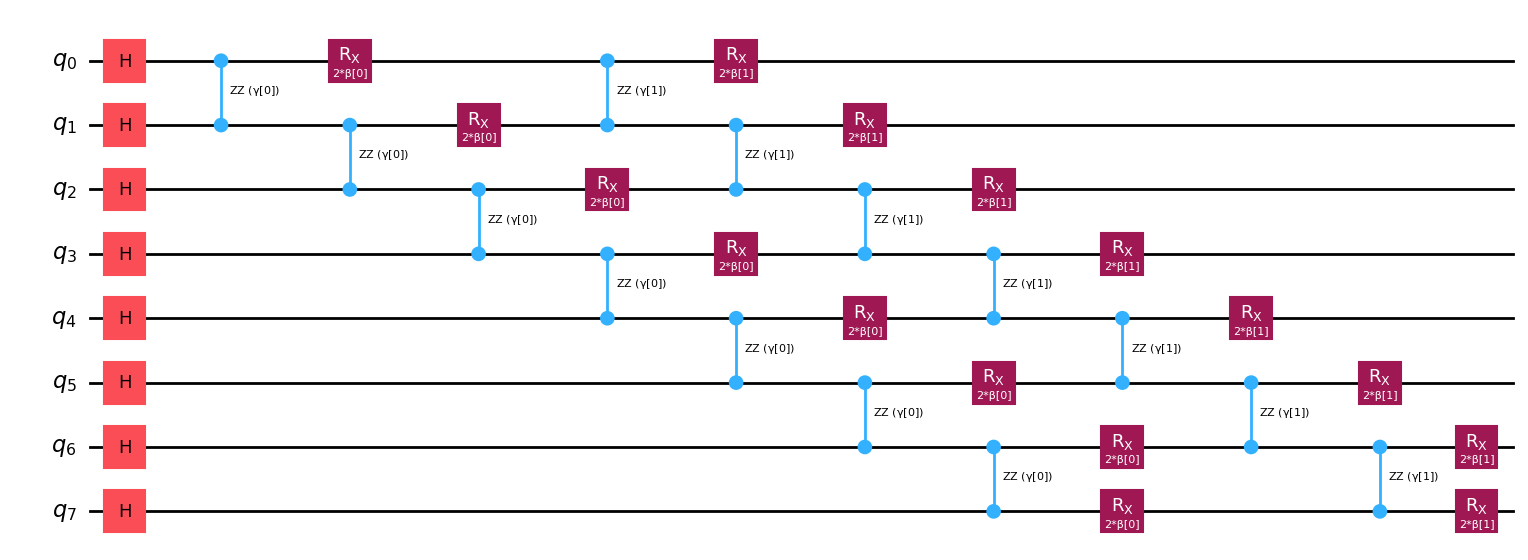

In [4]:
from qiskit.transpiler import generate_preset_pass_manager

pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
isa_circuit = pm.run(circuit)
isa_observable = observable.apply_layout(isa_circuit.layout)
print(f">>> Circuit ops (ISA): {isa_circuit.count_ops()}")
isa_circuit.draw("mpl")

In [5]:
from qiskit_ibm_runtime import EstimatorV2 as Estimator

estimator = Estimator(mode=backend)

In [6]:
job = estimator.run([(isa_circuit, isa_observable, np.array([param_values,param_values]))])
print(f">>> Job ID: {job.job_id()}")
print(f">>> Job Status: {job.status()}")

>>> Job ID: 19597b16-191e-4680-b5e9-8bf30b6f2c11
>>> Job Status: JobStatus.RUNNING


In [7]:
result = job.result()
print(f">>> {result}")
print(f">>> {result[0]}")
print(f"  > Expectation value: {result[0].data.evs}")
print(f"  > Metadata: {result[0].metadata}")

>>> PrimitiveResult([PubResult(data=DataBin(evs=np.ndarray(<shape=(2,), dtype=float64>), stds=np.ndarray(<shape=(2,), dtype=float64>), shape=(2,)), metadata={'target_precision': 0.015625, 'shots': 4096, 'circuit_metadata': {}})], metadata={'version': 2})
>>> PubResult(data=DataBin(evs=np.ndarray(<shape=(2,), dtype=float64>), stds=np.ndarray(<shape=(2,), dtype=float64>), shape=(2,)), metadata={'target_precision': 0.015625, 'shots': 4096, 'circuit_metadata': {}})
  > Expectation value: [1.5546875  1.56225586]
  > Metadata: {'target_precision': 0.015625, 'shots': 4096, 'circuit_metadata': {}}


In [8]:
from solver.circuits import HardwareAdaptAnsatz23
from qiskit import QuantumCircuit
test = HardwareAdaptAnsatz23(8)
test_gate = test.gate_pool[66]
print(test_gate(Parameter("A")).label)
print(test_gate((Parameter("A"))).name)

XXXXXXXX
YXXXXXXX
ZXXXXXXX
IXXXXXXX
XYXXXXXX
YYXXXXXX
ZYXXXXXX
IYXXXXXX
XZXXXXXX
YZXXXXXX
ZZXXXXXX
IZXXXXXX
XIXXXXXX
YIXXXXXX
ZIXXXXXX
IIXXXXXX
XXYXXXXX
YXYXXXXX
ZXYXXXXX
IXYXXXXX
XYYXXXXX
YYYXXXXX
ZYYXXXXX
IYYXXXXX
XZYXXXXX
YZYXXXXX
ZZYXXXXX
IZYXXXXX
XIYXXXXX
YIYXXXXX
ZIYXXXXX
IIYXXXXX
XXZXXXXX
YXZXXXXX
ZXZXXXXX
IXZXXXXX
XYZXXXXX
YYZXXXXX
ZYZXXXXX
IYZXXXXX
XZZXXXXX
YZZXXXXX
ZZZXXXXX
IZZXXXXX
XIZXXXXX
YIZXXXXX
ZIZXXXXX
IIZXXXXX
XXIXXXXX
YXIXXXXX
ZXIXXXXX
IXIXXXXX
XYIXXXXX
YYIXXXXX
ZYIXXXXX
IYIXXXXX
XZIXXXXX
YZIXXXXX
ZZIXXXXX
IZIXXXXX
XIIXXXXX
YIIXXXXX
ZIIXXXXX
IIIXXXXX
XXXYXXXX
YXXYXXXX
ZXXYXXXX
IXXYXXXX
XYXYXXXX
YYXYXXXX
ZYXYXXXX
IYXYXXXX
XZXYXXXX
YZXYXXXX
ZZXYXXXX
IZXYXXXX
XIXYXXXX
YIXYXXXX
ZIXYXXXX
IIXYXXXX
XXYYXXXX
YXYYXXXX
ZXYYXXXX
IXYYXXXX
XYYYXXXX
YYYYXXXX
ZYYYXXXX
IYYYXXXX
XZYYXXXX
YZYYXXXX
ZZYYXXXX
IZYYXXXX
XIYYXXXX
YIYYXXXX
ZIYYXXXX
IIYYXXXX
XXZYXXXX
YXZYXXXX
ZXZYXXXX
IXZYXXXX
XYZYXXXX
YYZYXXXX
ZYZYXXXX
IYZYXXXX
XZZYXXXX
YZZYXXXX
ZZZYXXXX
IZZYXXXX
XIZYXXXX
YIZYXXXX
ZIZYXXXX
I

$R_{ZXXYXXXX}$
PauliEvolution


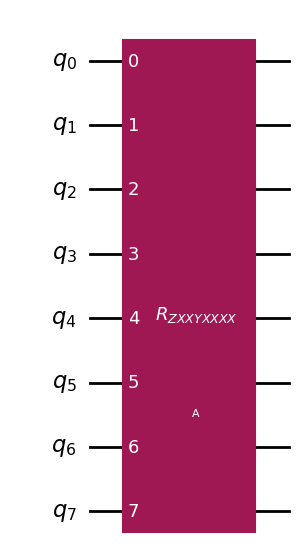

In [9]:
qc = QuantumCircuit(8)
test_gate = test.gate_pool[66](Parameter("A"))
qc.append(test_gate,list(range(8)))
isa_qc = pm.run(qc)
print(test_gate.label)
print(test_gate.name)
qc.draw("mpl")

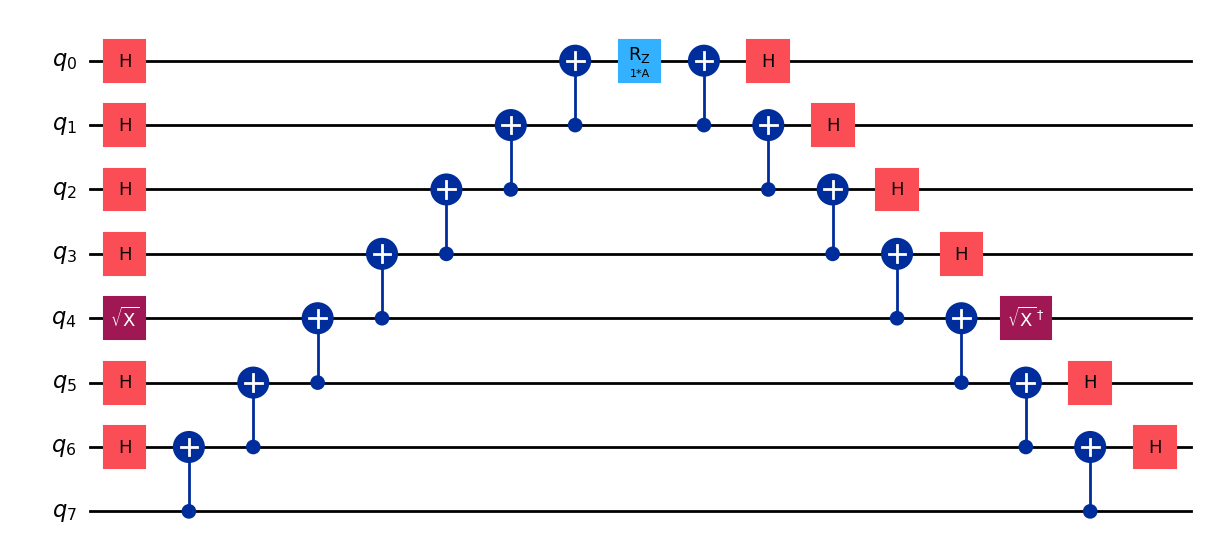

In [10]:
isa_qc.draw("mpl")

$R_{XXXYXXXZ}$
PauliEvolution


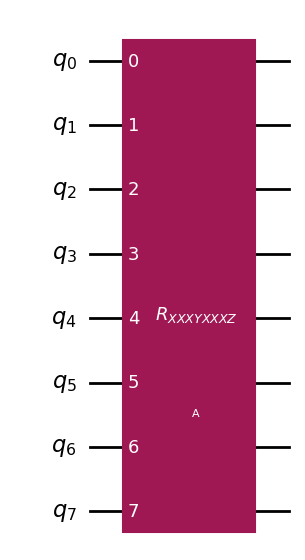

In [11]:
qc = QuantumCircuit(8)
test_gate = test.gate_pool[32832](Parameter("A"))
qc.append(test_gate,list(range(8)))
isa_qc = pm.run(qc)
print(test_gate.label)
print(test_gate.name)
qc.draw("mpl")

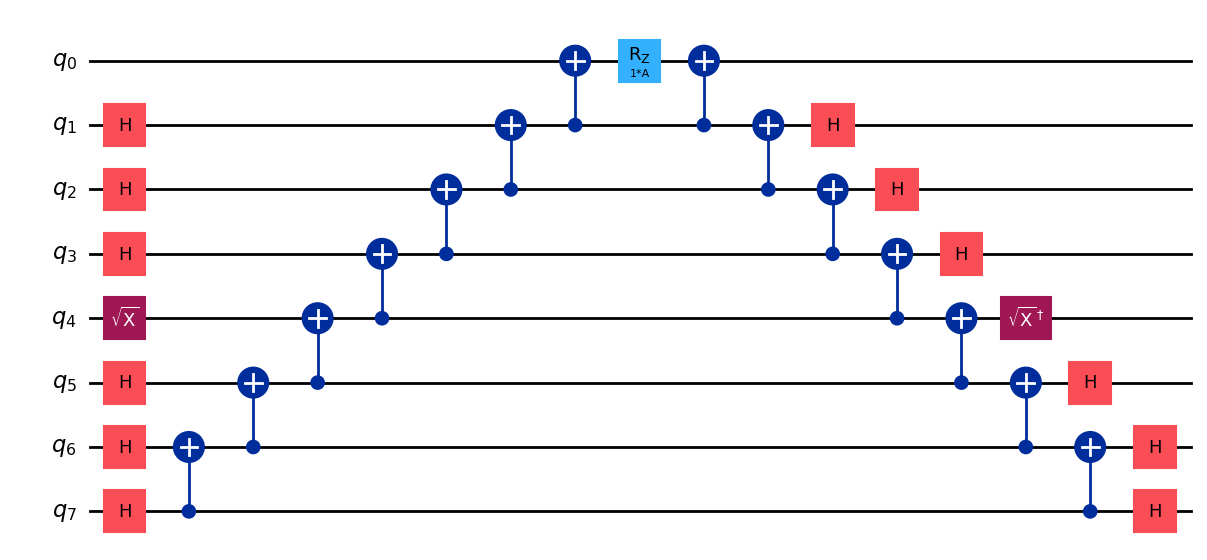

In [12]:
isa_qc.draw("mpl")

In [13]:
pauli_gates[4545].time = 42

In [14]:
pauli_gates[4545].validate_parameter(42)

42.0

In [15]:
test.operator_pool[-1].to_list()[0][0]

'ZIIIIIII'